# Check tensorflow and torch GPU

In [1]:
import tensorflow as tf
import torch

1
True


# Import important libraries

In [3]:

import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Activation, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from skimage import transform

In [4]:
import cv2
image = cv2.imread("/kaggle/input/autistic-children-facial-data-set/train/autistic/0002.jpg")
height, width = image.shape[:2]




Image height: 224 pixels
Image width: 224 pixels


In [5]:
photo_size=240

# Prepare dataset and add some augmentation

In [6]:
def prepare_dataset(data_dir):
    datagen = ImageDataGenerator(
        rescale=1 / 255,
        rotation_range=90,
        width_shift_range=.2,
        height_shift_range=.2,
        shear_range=.1,
        horizontal_flip=True,
        fill_mode='nearest',
        zoom_range=.2,
    )
    generator = datagen.flow_from_directory(
        data_dir,
        target_size=(photo_size,photo_size),
        class_mode='binary',
        batch_size=128,
        classes=['non_autistic','autistic']
    )
    return generator

# Load Dataset from directory

In [7]:
train_data=prepare_dataset('../input/autistic-children-facial-data-set/train/')
validation_data = prepare_dataset('../input/autistic-children-facial-data-set/valid/')
test_data=prepare_dataset('../input/autistic-children-facial-data-set/test/')


Found 2536 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 300 images belonging to 2 classes.


In [9]:
train_data.class_indices

{'non_autistic': 0, 'autistic': 1}

# Load pre-trained models

In [10]:
!pip install efficientnet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.5 MB/s eta 0:00:00


# Efficient net

In [11]:
def use_efficient_net(model_type='B0'):
    from tensorflow.keras.optimizers import RMSprop
    from keras.models import Model
    import efficientnet.tfkeras as efn
    if model_type=='B0':
        efn_model = efn.EfficientNetB0(input_shape = (photo_size, photo_size, 3), include_top = False, weights = 'imagenet')
    else:
        efn_model = efn.EfficientNetB7(input_shape = (photo_size, photo_size, 3), include_top = False, weights = 'imagenet')
    for layer in efn_model.layers:
        layer.trainable = False
    #
    x = efn_model.output
    x = Flatten()(x)
    x = Dense(256, activation="relu")(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    # Add a final sigmoid layer with 1 node for classification output
    predictions = Dense(1, activation="sigmoid")(x)
    efficient_net = Model(efn_model.input,predictions)

    efficient_net.compile(RMSprop(learning_rate=0.0001, decay=1e-6),loss='binary_crossentropy',metrics=['accuracy'])
    return efficient_net
efficient_net=use_efficient_net('B7')
# efficient_net.summary()

258449408/258434480 [==============================] - 1s 0us/step


In [12]:
effb7_history = efficient_net.fit(train_data, validation_data = validation_data, epochs = 100)
efficient_net.save("efficient_net_B7_model.h5")

Epoch 1/100
20/20 [==============================] - 90s 3s/step - loss: 1.3503 - accuracy: 0.5678 - val_loss: 0.6321 - val_accuracy: 0.6100
Epoch 2/100
20/20 [==============================] - 44s 2s/step - loss: 0.7186 - accuracy: 0.6262 - val_loss: 0.6531 - val_accuracy: 0.6900
Epoch 3/100
20/20 [==============================] - 45s 2s/step - loss: 0.6702 - accuracy: 0.6518 - val_loss: 0.5491 - val_accuracy: 0.7000
Epoch 4/100
20/20 [==============================] - 45s 2s/step - loss: 0.6630 - accuracy: 0.6502 - val_loss: 0.6100 - val_accuracy: 0.6400
Epoch 5/100
20/20 [==============================] - 44s 2s/step - loss: 0.6270 - accuracy: 0.6794 - val_loss: 0.5201 - val_accuracy: 0.7400
Epoch 6/100
20/20 [==============================] - 44s 2s/step - loss: 0.5967 - accuracy: 0.6924 - val_loss: 0.5437 - val_accuracy: 0.7500
Epoch 7/100
20/20 [==============================] - 47s 2s/step - loss: 0.5988 - accuracy: 0.6976 - val_loss: 0.5232 - val_accuracy: 0.7500
Epoch 8/100
2

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [13]:
import tensorflow as tf

# Load the model
model_path = '/kaggle/input/facial_for_autism_detection/tensorflow2/model1/1/efficient_net_B7_model.h5'
model = tf.keras.models.load_model(model_path)

    


## Load Images from path

In [37]:
from PIL import Image
import numpy as np
from skimage import transform
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
photo_size=224
def load_image_from_path(filename):
    img = mpimg.imread(filename)
    np_image = Image.open(filename)
    np_image = np.array(np_image).astype('float32') / 255
    np_image = transform.resize(np_image, (240, 240, 3))
    np_image = np.expand_dims(np_image, axis=0)
    return np_image

In [38]:
label= []
predicted = []

In [39]:
import os
import numpy as np

mTestPath = "/kaggle/input/autistic-children-facial-data-set/test/autistic"

for test in os.listdir(mTestPath):
    
    img = load_image_from_path(os.path.join(mTestPath, test))
    label.append(1)
    pre = model.predict(img)
    res = pre[0][0]  # Extract the predicted probability from the output array
    
    
    
    
    if res > 0.5:
        predicted.append(1)
        
        
    else:
        predicted.append(0)
        
        


029.jpg
[[0.99060327]]
0.99060327
Efficient-NetB7	Autistic
014.jpg
[[0.9142816]]
0.9142816
Efficient-NetB7	Autistic
150.jpg
[[0.9628721]]
0.9628721
Efficient-NetB7	Autistic
109.jpg
[[0.98505914]]
0.98505914
Efficient-NetB7	Autistic
034.jpg
[[0.9789611]]
0.9789611
Efficient-NetB7	Autistic
149.jpg
[[0.95367324]]
0.95367324
Efficient-NetB7	Autistic
024.jpg
[[0.7578315]]
0.7578315
Efficient-NetB7	Autistic
033.jpg
[[0.78037804]]
0.78037804
Efficient-NetB7	Autistic
094.jpg
[[0.7473165]]
0.7473165
Efficient-NetB7	Autistic
049.jpg
[[0.6663461]]
0.6663461
Efficient-NetB7	Autistic
048.jpg
[[0.96340877]]
0.96340877
Efficient-NetB7	Autistic
143.jpg
[[0.9750919]]
0.9750919
Efficient-NetB7	Autistic
115.jpg
[[0.71458006]]
0.71458006
Efficient-NetB7	Autistic
131.jpg
[[0.9417438]]
0.9417438
Efficient-NetB7	Autistic
080.jpg
[[0.46631223]]
0.46631223
Efficient-NetB7	Non_Autistic
062.jpg
[[0.8060229]]
0.8060229
Efficient-NetB7	Autistic
118.jpg
[[0.99621296]]
0.99621296
Efficient-NetB7	Autistic
067.jpg
[[0

In [40]:
import os
import numpy as np

mTestPath = "/kaggle/input/autistic-children-facial-data-set/test/non_autistic"

for test in os.listdir(mTestPath):
    
    img = load_image_from_path(os.path.join(mTestPath, test))
    label.append(0)
    pre = model.predict(img)
    res = pre[0][0]  # Extract the predicted probability from the output array
    
    
    
    
    if res > 0.5:
        predicted.append(1)
        
        
    else:
        predicted.append(0)
        
        


029.jpg
[[0.04373614]]
0.043736137
Efficient-NetB7	Non_Autistic
014.jpg
[[0.2778045]]
0.2778045
Efficient-NetB7	Non_Autistic
150.jpg
[[0.0400257]]
0.040025696
Efficient-NetB7	Non_Autistic
109.jpg
[[0.3468816]]
0.3468816
Efficient-NetB7	Non_Autistic
034.jpg
[[0.01542373]]
0.015423726
Efficient-NetB7	Non_Autistic
149.jpg
[[0.03177719]]
0.031777192
Efficient-NetB7	Non_Autistic
024.jpg
[[0.16342157]]
0.16342157
Efficient-NetB7	Non_Autistic
033.jpg
[[0.14991657]]
0.14991657
Efficient-NetB7	Non_Autistic
094.jpg
[[0.09302696]]
0.09302696
Efficient-NetB7	Non_Autistic
049.jpg
[[0.5506618]]
0.5506618
Efficient-NetB7	Autistic
048.jpg
[[0.21133414]]
0.21133414
Efficient-NetB7	Non_Autistic
143.jpg
[[0.01634085]]
0.016340848
Efficient-NetB7	Non_Autistic
115.jpg
[[0.06096119]]
0.06096119
Efficient-NetB7	Non_Autistic
131.jpg
[[0.07146782]]
0.07146782
Efficient-NetB7	Non_Autistic
080.jpg
[[0.05845903]]
0.05845903
Efficient-NetB7	Non_Autistic
062.jpg
[[0.2737531]]
0.2737531
Efficient-NetB7	Non_Autistic


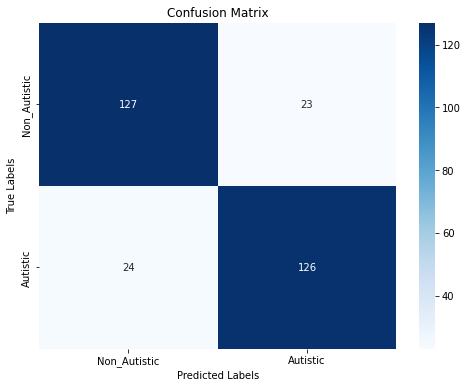

In [42]:
import os
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
conf_matrix = confusion_matrix(label, predicted)

# Define class labels
class_labels = ['Non_Autistic', 'Autistic']

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

# Save the confusion matrix as an image
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()


In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute precision, recall, and F1 score
precision = precision_score(label, predicted)
recall = recall_score(label, predicted)
f1 = f1_score(label, predicted)






Precision: 0.8456375838926175
Recall: 0.84
F1 Score: 0.842809364548495


In [44]:
%pip install tf2onnx 


%pip install onnxruntime
%pip install h5py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 8.2 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 30.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [45]:
import onnx
import os

import tf2onnx 



onnx_model, _ = tf2onnx.convert.from_keras(model)

onnx.save(onnx_model, 'efficinietb7_onnx_100epochs.onnx')

In [46]:
import onnxruntime

session = onnxruntime.InferenceSession("/kaggle/working/efficinietb7_onnx_100epochs.onnx")
session.get_inputs()[0].shape
session.get_inputs()[0].type


input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

from PIL import Image
import numpy as np
from skimage import transform
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
photo_size=224
def load_image_from_path(filename):
    img = mpimg.imread(filename)
    np_image = Image.open(filename)
    np_image = np.array(np_image).astype('float32') / 255
    np_image = transform.resize(np_image, (240, 240, 3))
    np_image = np.expand_dims(np_image, axis=0)
    return np_image
test_img_input_onnx = load_image_from_path("/kaggle/input/autistic-children-facial-data-set/test/non_autistic/003.jpg")
result = session.run([output_name], {input_name: test_img_input_onnx})


[array([[0.31569552]], dtype=float32)]
